In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('/content/Sample - Superstore.csv', encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [8]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

(9994, 21)

In [9]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [12]:
df.duplicated().sum()
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [11]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [15]:
df = df.drop_duplicates()


In [17]:
# Which category makes the most profit?
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
print(category_profit)

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


In [21]:
# Which region performs best?
region_sales = df.groupby('Region')[['Sales', 'Profit']].sum().sort_values('Profit', ascending=False)
print(region_sales)


               Sales       Profit
Region                           
West     725457.8245  108418.4489
East     678781.2400   91522.7800
South    391721.9050   46749.4303
Central  501239.8908   39706.3625


In [20]:
# Are there products/categories losing money despite sales?
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()
print(subcat_profit)

Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1189.0995
Fasteners        949.5182
Machines        3384.7569
Labels          5546.2540
Art             6527.7870
Envelopes       6964.1767
Furnishings    13059.1436
Appliances     18138.0054
Storage        21278.8264
Chairs         26590.1663
Binders        30221.7633
Paper          34053.5693
Accessories    41936.6357
Phones         44515.7306
Copiers        55617.8249
Name: Profit, dtype: float64


In [22]:
# Does discount level relate to profit loss?
df.groupby('Discount')['Profit'].mean()

,Profit
Discount,
0.00,66.900292
0.10,96.055074
0.15,27.288298
0.20,24.702572
0.30,-45.679636
0.32,-88.560656
0.40,-111.927429
0.45,-226.646464
0.50,-310.703456


**Analysis**

/tmp/ipykernel_606/92938445.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='Discount', y='Profit', data=df, estimator='mean', ci=None)


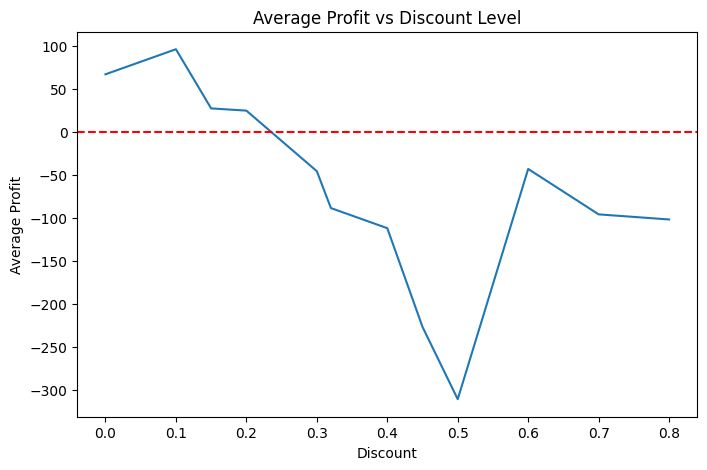

In [23]:
# Discount vs profit Analysis
plt.figure(figsize=(8,5))
sns.lineplot(x='Discount', y='Profit', data=df, estimator='mean', ci=None)
plt.title('Average Profit vs Discount Level')
plt.xlabel('Discount')
plt.ylabel('Average Profit')
plt.axhline(0, color='red', linestyle='--')  # shows where profit turns negative
plt.show()

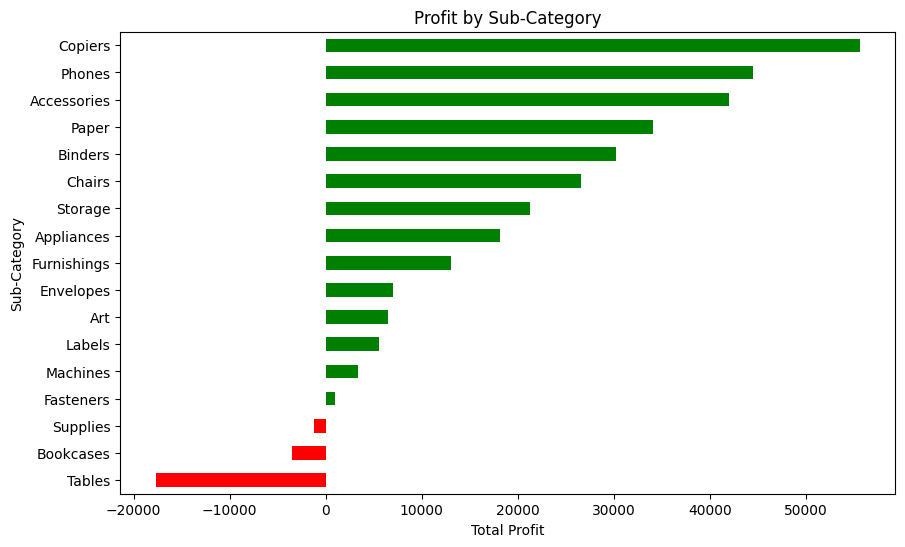

In [24]:
plt.figure(figsize=(10,6))
subcat_profit.plot(kind='barh', color=(subcat_profit > 0).map({True: 'green', False: 'red'}))
plt.title('Profit by Sub-Category')
plt.xlabel('Total Profit')
plt.show()

# Superstore Sales Analysis

## Objective
Analyzed sales and profit data from a retail superstore to identify
performance patterns across categories, regions, and discount strategies.

## Key Findings

1. **Technology drives the most profit**, while [West region] leads in
   both sales and profitability — suggesting [your interpretation, e.g.,
   "marketing/inventory focus should prioritize these areas"].

2. **Tables are consistently unprofitable** despite steady sales volume —
   indicating a pricing or discounting problem specific to this sub-category.

3. **Discounts above [10]% actively erode profit.** Average profit turns
   negative once discounts exceed roughly [10]%, meaning the
   company may be discounting past the point of profitability on many orders.

## Recommendation
Based on this analysis, the business should reconsider discount policy
on Tables specifically, and cap discounts around [10]% company-wide to
protect margins, unless volume gains clearly offset the loss.